In [1]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (LogisticRegression, LogisticRegressionCV,
                                  RidgeClassifier, SGDClassifier,
                                  PassiveAggressiveClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, ExtraTreesClassifier)
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.discriminant_analysis import (QuadraticDiscriminantAnalysis,
                                           LinearDiscriminantAnalysis)
from sklearn.feature_selection import SelectFromModel

only_passed_bill_traces = True


# Berlin:
start_date_berlin = "2006-10-26"
end_date_berlin = "2021-11-04"
INPUT_FILE_NAME_BERLIN = './data-csv/case-logs/Berlin-with-topics-and-agreement-scores-all-time.csv'


# Brandenburg:
start_date_brandenburg = "2004-10-13"
end_date_brandenburg = "2019-09-25"
INPUT_FILE_NAME_BRANDENBURG = './data-csv/case-logs/Brandenburg-with-topics-and-agreement-scores-all-time-preprocessed.csv'

# Baden-Württemberg:
INPUT_FILE_NAME_BAWUE = './data-csv/case-logs/Baden-Württemberg-with-topics-and-agreement-scores-all-time-preprocessed.csv'
start_date_bawue = "2006-06-01"
end_date_bawue = "2021-05-01"




In [2]:
DATA_TYPES = {}

df_berlin = pd.read_csv(INPUT_FILE_NAME_BERLIN, dtype=DATA_TYPES)
print('Read', len(df_berlin), 'rows from', INPUT_FILE_NAME_BERLIN)
df_berlin = df_berlin.dropna(axis=1, how='all')  # drop all completely empty columns

df_brandenburg = pd.read_csv(INPUT_FILE_NAME_BRANDENBURG, dtype=DATA_TYPES)
print('Read', len(df_brandenburg), 'rows from', INPUT_FILE_NAME_BRANDENBURG)
df_brandenburg = df_brandenburg.dropna(axis=1, how='all')  # drop all completely empty columns

df_bawue = pd.read_csv(INPUT_FILE_NAME_BAWUE, dtype=DATA_TYPES)
print('Read', len(df_bawue), 'rows from', INPUT_FILE_NAME_BAWUE)
df_bawue = df_bawue.dropna(axis=1, how='all')  # drop all completely empty columns
#df.info(verbose=True)

if only_passed_bill_traces:
    df_berlin = df_berlin[df_berlin['case:is_passed_bill'] == 1]
    print('Filtered to only passed bill traces, remaining rows berlin:', len(df_berlin))
    df_brandenburg = df_brandenburg[df_brandenburg['case:is_passed_bill'] == 1]
    print('Filtered to only passed bill traces, remaining rows brandenburg:', len(df_brandenburg))
    df_bawue = df_bawue[df_bawue['case:is_passed_bill'] == 1]
    print('Filtered to only passed bill traces, remaining rows bawue:', len(df_bawue))

Read 1813 rows from ./data-csv/case-logs/Berlin-with-topics-and-agreement-scores-all-time.csv
Read 1410 rows from ./data-csv/case-logs/Brandenburg-with-topics-and-agreement-scores-all-time-preprocessed.csv
Read 1465 rows from ./data-csv/case-logs/Baden-Württemberg-with-topics-and-agreement-scores-all-time-preprocessed.csv
Filtered to only passed bill traces, remaining rows berlin: 1313
Filtered to only passed bill traces, remaining rows brandenburg: 1092
Filtered to only passed bill traces, remaining rows bawue: 833


In [3]:
# filter the data by date

print("------------------ Berlin, Brandenburg, Baden-Württemberg")
print("df rows before filtering by date:", str(len(df_berlin)) + ", " + str(len(df_brandenburg)) + ", " + str(len(df_bawue)))

# Calculate end_date by adding duration (in days) to start_time
df_berlin['end_time'] = pd.to_datetime(df_berlin['start_time']) + pd.to_timedelta(df_berlin['duration'], unit='D')
df_berlin = df_berlin[(df_berlin['start_time'] >= start_date_berlin) & (df_berlin['end_time'] <= end_date_berlin)]

df_brandenburg['end_time'] = pd.to_datetime(df_brandenburg['start_time']) + pd.to_timedelta(df_brandenburg['duration'], unit='D')
df_brandenburg = df_brandenburg[(df_brandenburg['start_time'] >= start_date_brandenburg) & (df_brandenburg['end_time'] <= end_date_brandenburg)]

df_bawue['end_time'] = pd.to_datetime(df_bawue['start_time']) + pd.to_timedelta(df_bawue['duration'], unit='D')
df_bawue = df_bawue[(df_bawue['start_time'] >= start_date_bawue) & (df_bawue['end_time'] <= end_date_bawue)]

df_berlin.drop(columns=['end_time'], inplace=True)
df_brandenburg.drop(columns=['end_time'], inplace=True)
df_bawue.drop(columns=['end_time'], inplace=True)

print("df rows after filtering by date:", str(len(df_berlin)) + ", " + str(len(df_brandenburg)) + ", " + str(len(df_bawue)))

------------------ Berlin, Brandenburg, Baden-Württemberg
df rows before filtering by date: 1313, 1092, 833
df rows after filtering by date: 501, 440, 335


In [4]:
# compute mean cycle time to compare against - cases taking longer than 10% above the mean cycle time are considered "long-running" cases

bawue_average_cycle_time = df_bawue["duration"].mean()
bawue_average_cycle_time_upper_bound = bawue_average_cycle_time + 0.1*bawue_average_cycle_time
bawue_average_cycle_time_lower_bound = bawue_average_cycle_time - 0.1*bawue_average_cycle_time

outcome_function = lambda row: row['duration'] > bawue_average_cycle_time_upper_bound

print("average_cycle_time:", bawue_average_cycle_time_upper_bound)

average_cycle_time: 100.07701492537313


In [5]:
# split into data and target
target_berlin = df_berlin.apply(outcome_function, axis=1)
target_brandenburg = df_brandenburg.apply(outcome_function, axis=1)
target_bawue = df_bawue.apply(outcome_function, axis=1)
data_berlin = df_berlin
data_brandenburg = df_brandenburg
data_bawue = df_bawue

print("target value counts berlin:", target_berlin.value_counts())
print("target value counts brandenburg:", target_brandenburg.value_counts())
print("target value counts bawue:", target_bawue.value_counts())

target value counts berlin: False    266
True     235
Name: count, dtype: int64
target value counts brandenburg: True     272
False    168
Name: count, dtype: int64
target value counts bawue: False    252
True      83
Name: count, dtype: int64


In [6]:
for data in [data_berlin, data_brandenburg, data_bawue]:
    columns_type_object = data.select_dtypes(include=['object']).columns
    print("Dropping columns of type object:", columns_type_object)
    data.drop(columns=columns_type_object, inplace=True)
    data.fillna(0, inplace=True)

datasets_raw = {
    'Berlin':           (data_berlin, target_berlin),
    'Brandenburg':      (data_brandenburg, target_brandenburg),
    #'Baden-Württemberg': (data_bawue, target_bawue),
}

Dropping columns of type object: Index(['start_time', 'case:DokTypLFirstDoc', 'case:VorgangsDeskriptoren',
       'case:VSysL'],
      dtype='object')
Dropping columns of type object: Index(['start_time', 'case:DokTypLFirstDoc', 'case:VSysL',
       'case:VorgangsDeskriptoren'],
      dtype='object')
Dropping columns of type object: Index(['start_time', 'case:DokTypLFirstDoc', 'case:VSysL',
       'case:VorgangsDeskriptoren', 'case:author_first_activity'],
      dtype='object')


## Classifiers

In [7]:
def get_classifiers():
    return {
        "Random Baseline":      "random",
        "Majority Baseline":    "majority",
        "Logistic Regression":  LogisticRegression(max_iter=1000, random_state=42),
        "Random Forest":        RandomForestClassifier(max_depth=5, n_estimators=100, random_state=42),
        "Decision Tree":        DecisionTreeClassifier(max_depth=5, random_state=42),
        "Linear SVM":           SVC(kernel="linear", C=0.025, random_state=42),
        "Ridge Classifier":     RidgeClassifier(random_state=42),
        "SGD Classifier":       SGDClassifier(random_state=42, max_iter=1000),
        "Passive Aggressive":   PassiveAggressiveClassifier(random_state=42, max_iter=1000),
        "K-Nearest Neighbors":  KNeighborsClassifier(3),
        "RBF SVM":              SVC(gamma=2, C=1, random_state=42),
        "Gaussian Process":     GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42),
        "Extra Trees":          ExtraTreesClassifier(max_depth=5, n_estimators=100, random_state=42),
        "Gradient Boosting":    GradientBoostingClassifier(random_state=42),
         "AdaBoost":           AdaBoostClassifier(random_state=42),
        "Neural Net (MLP)":     MLPClassifier(alpha=1, max_iter=1000, random_state=42),
        "LDA":                  LinearDiscriminantAnalysis(),
    }

## Feature Groups

In [8]:
# columns to always hide
ALWAYS_HIDE = [
    'duration',
    r'.*cycle.*',
    r'.*Gesetz(?!entwurf).*', '.*Bekanntmachung.*',
    'case_id',
    r'.*none.*',
    # r'.*nan.*',
    r'(?i).*\bnan\b.*',   # only match 'nan' as a whole word
    'start_time_rel', 'start_time', 'end_time', r'.*\.start.*',
    r'.*delay.*',         # should be always hidden?
]

CONTROL_FLOW_FEATURES = [
    # r'.*delay.*',
    "event_count",
    r'.*\.count.*',
]

POLITICAL_FEATURES = [
    r'.*score.*',
    "case:is_election_year",
    "case:is_passed_bill",
    "case:Wp",
    "case:WIP_during_start",
    "case:half_year_index",
    "case:government_party_count",
    "case:opposition_party_count",
    "case:author_first_event_count",
    r'case:author_first_event_.*',
    r'case:vsysl.*',
    r'case:deskriptor_.*',
    "case:opposition_seat_percentage",
    "case:government_seat_percentage",
    "case:pdf_bytes", "case:pdf_word_count",
]

# --- Political features split by data provenance ---------------------------
# Union of these two == original POLITICAL_FEATURES (keeps existing sets valid).

OUT_OF_DATA_POLITICAL_FEATURES = [
    r'.*score.*',                       # Wahl-O-Mat agreement (party alignment)
    "case:government_party_count",      # parliamentary composition
    "case:opposition_party_count",
    "case:government_seat_percentage",
    "case:opposition_seat_percentage",
    "case:is_election_year",            # electoral calendar  (JUDGMENT CALL, see notes)
    "case:half_year_index",            # temporal position from log timestamps (JUDGMENT CALL)
    "case:pdf_bytes", "case:pdf_word_count",   # business-object props (JUDGMENT CALL)
]

IN_DATA_POLITICAL_FEATURES = [
    "case:is_passed_bill",              # constant after filtering -> will be dropped
    "case:Wp",
    "case:WIP_during_start",            # active processes at start: computed from log
    "case:author_first_event_count",
    r'case:author_first_event_.*',
    r'case:vsysl.*',                    # Systematik (topic) from source data
    r'case:deskriptor_.*',             # descriptors from source data
]



# each test case = list of hide patterns. ALWAYS_HIDE is included in all.
'''
test_cases = {
    'Without political features': ALWAYS_HIDE + POLITICAL_FEATURES,    # keep control-flow
    'Political features only':    ALWAYS_HIDE + CONTROL_FLOW_FEATURES,  # keep political
    'Combined':          ALWAYS_HIDE,                          # keep both
}
'''

test_cases = {
    # --- existing ---
    'Without political features': ALWAYS_HIDE + POLITICAL_FEATURES, # keep control-flow
    'Political features only':    ALWAYS_HIDE + CONTROL_FLOW_FEATURES, # keep political
    'Combined':                   ALWAYS_HIDE, # keep both

    # --- political-only isolation (hide control-flow + the other provenance) ---
    'In-data political only':
        ALWAYS_HIDE + CONTROL_FLOW_FEATURES + OUT_OF_DATA_POLITICAL_FEATURES,
    'Out-of-data political only':
        ALWAYS_HIDE + CONTROL_FLOW_FEATURES + IN_DATA_POLITICAL_FEATURES,

    # --- added on top of control-flow (the claim-relevant comparisons) ---
    'Control-flow + in-data political':
        ALWAYS_HIDE + OUT_OF_DATA_POLITICAL_FEATURES,
    'Control-flow + out-of-data political':
        ALWAYS_HIDE + IN_DATA_POLITICAL_FEATURES,
}

In [9]:
# 10-fold stratified CV evaluation, leakage-free.
# Same folds across all classifiers and feature sets within a region.
# Standardization (and any fitted preprocessing) happens inside each
# training fold via the pipeline. Per-fold mean ± std reported.
import numpy as np
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

N_SPLITS = 5
SEED = 42
STD_DDOF = 1   # sample std across folds; set 0 for population std

scoring = {
    'accuracy':  'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall':    make_scorer(recall_score,    zero_division=0),
    'f1':        make_scorer(f1_score,         zero_division=0),
}

def as_estimator(clf):
    if clf == "random":     # class-proportional random guesser
        return DummyClassifier(strategy="stratified", random_state=SEED)
    if clf == "majority":   # always predict the majority class
        return DummyClassifier(strategy="most_frequent")
    return make_pipeline(StandardScaler(), clf)   # scaler refit per training fold

all_scores = []

for region, (data_raw, target) in datasets_raw.items():
    for case_name, hide_patterns in test_cases.items(): 

        # apply feature hiding
        data_filtered = data_raw.copy()
        for pattern in hide_patterns:
            for col in list(data_filtered.columns):
                if re.fullmatch(pattern, col):
                    data_filtered = data_filtered.drop(columns=[col])

        X = data_filtered.to_numpy()
        y = target.to_numpy()

        # splits depend only on (y, n, SEED) -> identical folds for every
        # classifier and every feature set within the region
        skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

        for method_name, clf in get_classifiers().items():
            try:
                cv = cross_validate(as_estimator(clf), X, y, cv=skf,
                                    scoring=scoring, n_jobs=-1)
                all_scores.append({
                    'case': case_name, 'region': region, 'method': method_name,
                    'accuracy_mean':  cv['test_accuracy'].mean(),
                    'accuracy_std':   cv['test_accuracy'].std(ddof=STD_DDOF),
                    'precision_mean': cv['test_precision'].mean(),
                    'precision_std':  cv['test_precision'].std(ddof=STD_DDOF),
                    'recall_mean':    cv['test_recall'].mean(),
                    'recall_std':     cv['test_recall'].std(ddof=STD_DDOF),
                    'f1_mean':        cv['test_f1'].mean(),
                    'f1_std':         cv['test_f1'].std(ddof=STD_DDOF),
                })
            except Exception as e:
                print(f"  [skip] {method_name} on {region}/{case_name}: "
                      f"{type(e).__name__}: {e}")
                all_scores.append({
                    'case': case_name, 'region': region, 'method': method_name,
                    'accuracy_mean':  np.nan, 'accuracy_std':  np.nan,
                    'precision_mean': np.nan, 'precision_std': np.nan,
                    'recall_mean':    np.nan, 'recall_std':    np.nan,
                    'f1_mean':        np.nan, 'f1_std':         np.nan,
                })

scores_df = pd.DataFrame(all_scores)

# bridge: display/boxplot code reads flat metric columns. Alias the means so
# reorder_within_cases / style_region_table / boxplots work unchanged;
# the *_std columns stay in scores_df for error bars / paper tables.
for m in ['accuracy', 'precision', 'recall', 'f1']:
    scores_df[m] = scores_df[f'{m}_mean']

/Users/paul/miniconda3/envs/pm4py-env/lib/python3.13/site-packages/sklearn/gaussian_process/_gpc.py:485: RuntimeWarning: overflow encountered in exp
  - np.log1p(np.exp(-(self.y_train_ * 2 - 1) * f)).sum()


In [10]:
def reorder_within_cases(df):
    """Baselines first, then the rest sorted by f1 (within each case)."""
    baseline_order = ['Random Baseline', 'Majority Baseline']

    def sort_group(group):
        g = group.reset_index()
        is_baseline = g['method'].isin(baseline_order)
        baselines = g[is_baseline].copy()
        baselines['_ord'] = baselines['method'].map(
            {n: i for i, n in enumerate(baseline_order)})
        baselines = baselines.sort_values('_ord').drop(columns='_ord')
        rest = g[~is_baseline].sort_values('f1', ascending=False)
        return pd.concat([baselines, rest], ignore_index=True)

    case_order = df.index.get_level_values('case').unique().tolist()
    parts = []
    for case in case_order:
        sub = df.xs(case, level='case', drop_level=False)
        sorted_sub = sort_group(sub).set_index(['case', 'method'])
        parts.append(sorted_sub)
    return pd.concat(parts)

def style_region_table(region_df, region_name):
    metric_cols = ['accuracy', 'precision', 'recall', 'f1']

    # first row of each case group, for separator borders
    cases_in_order = region_df.index.get_level_values('case')
    first_row_positions, seen = [], set()
    for pos, case in enumerate(cases_in_order):
        if case not in seen:
            first_row_positions.append(pos)
            seen.add(case)
    separator_positions = first_row_positions[1:]

    def highlight_baselines(row):
        styles = [''] * len(row)
        method = row.name[1] if isinstance(row.name, tuple) else row.name
        if 'Baseline' in method:
            styles = ['color: #888; font-weight: bold'] * len(row)
        return styles

    def highlight_best_per_case(s):
        out = pd.Series('', index=s.index)
        for case in s.index.get_level_values('case').unique():
            sub = s.xs(case, level='case')
            sub_no_baseline = sub[~sub.index.str.contains('Baseline')]
            if sub_no_baseline.notna().any():
                best_val = sub_no_baseline.max()
                for method in sub_no_baseline.index:
                    if sub_no_baseline[method] == best_val:
                        out.loc[(case, method)] = \
                            'background-color: #b8e6b8; font-weight: bold'
        return out

    styled = (
        region_df
        .style
        .apply(highlight_baselines, axis=1)
        .apply(highlight_best_per_case, subset=metric_cols)
        .background_gradient(subset=metric_cols, cmap='RdYlGn',
                             vmin=0, vmax=1, axis=None)
        .format("{:.3f}", subset=metric_cols, na_rep="—")
        .set_caption(f"<h3 style='margin:10px 0'>{region_name}</h3>")
        .set_table_styles([
            {'selector': 'td', 'props': [('padding', '6px 12px'),
                                         ('text-align', 'right')]},
            {'selector': 'th', 'props': [('padding', '6px 12px'),
                                         ('text-align', 'left'),
                                         ('background-color', '#f5f5f5')]},
            {'selector': 'th.col_heading', 'props': [('text-align', 'center')]},
            {'selector': 'caption', 'props': [('caption-side', 'top'),
                                              ('text-align', 'left')]},
        ])
    )

    # full-width horizontal separators between case groups
    border_style = [{'selector': '', 'props': [('border-top',
                                                '2px solid #333')]}]
    for pos in separator_positions:
        styled = styled.set_table_styles(
            {region_df.index[pos]: border_style},
            overwrite=False, axis=1,
        )
    return styled


def show_region_tables(scores_df, metric='f1', exclude_baselines=True):
    """Display one styled table per region (for notebooks),
    plus a per-case median/mean/std summary across classifiers."""
    for region in datasets_raw.keys():
        region_df = scores_df[scores_df['region'] == region].copy()
        # keep only the four aliased metric columns; drop region + *_mean/*_std
        region_df = (region_df.set_index(['case', 'method'])
                     [['accuracy', 'precision', 'recall', 'f1']])
        region_df = reorder_within_cases(region_df)

        # --- per-case summary across classifiers ---
        summ_df = region_df
        if exclude_baselines:
            methods = summ_df.index.get_level_values('method')
            summ_df = summ_df[~methods.str.contains('Baseline')]

        case_order = region_df.index.get_level_values('case').unique()
        summary = (summ_df.groupby(level='case')[metric]
                   .agg(['median', 'mean', 'std'])
                   .reindex(case_order)
                   .round(3))

        try:
            from IPython.display import display
            display(style_region_table(region_df, region))
            print(f"{region} — {metric.upper()} per-case summary "
                  f"(across classifiers):")
            display(summary)
        except ImportError:
            print(f"\n### {region} ###")
            print(region_df.round(3).to_string())
            print(f"\n--- {region}: {metric.upper()} per-case summary "
                  f"(across classifiers) ---")
            print(summary.to_string())

In [11]:
show_region_tables(scores_df, metric='f1', exclude_baselines=False)

Berlin — F1 per-case summary (across classifiers):


,median,mean,std
case,,,
Without political features,0.520,0.473,0.152
Political features only,0.613,0.527,0.174
Combined,0.601,0.538,0.178
In-data political only,0.558,0.500,0.146
Out-of-data political only,0.567,0.511,0.174
Control-flow + in-data political,0.555,0.519,0.152
Control-flow + out-of-data political,0.584,0.538,0.149


Brandenburg — F1 per-case summary (across classifiers):


,median,mean,std
case,,,
Without political features,0.781,0.766,0.060
Political features only,0.752,0.726,0.048
Combined,0.750,0.757,0.048
In-data political only,0.723,0.716,0.049
Out-of-data political only,0.727,0.711,0.057
Control-flow + in-data political,0.762,0.764,0.042
Control-flow + out-of-data political,0.755,0.760,0.048


In [12]:
################
# boxplots 
# One subplot per parliament; within each, one box per feature set.
# Each box = F1 scores of all classifiers for that (region, case).

def plot_metric_boxplots_per_parliament(
        scores_df, exclude_baselines=True, figsize=(8, 4), metric='f1',
        case_order=None, label_map=None, color_map=None, fontsize=16):
    df = scores_df.copy()

    df_baselines = df[df['method'].str.contains('Baseline')].copy()
    if exclude_baselines:
        df = df[~df['method'].str.contains('Baseline')]

    region_order = df['region'].drop_duplicates().tolist()
    if case_order is None:
        case_order = df['case'].drop_duplicates().tolist()

    label_map = label_map or {}
    disp_labels = [label_map.get(c, c) for c in case_order]   # short axis labels

    cmap = plt.get_cmap('Set2')
    def box_color(case, i):
        if color_map and case in color_map:
            return color_map[case]
        return cmap(i % cmap.N)

    figs, axes = [], []
    for region in region_order:
        fig, ax = plt.subplots(figsize=figsize)
        region_df = df[df['region'] == region]

        positions = list(range(2, 2 + len(case_order)))
        data = [region_df.loc[region_df['case'] == c, metric].dropna().to_numpy()
                for c in case_order]

        bp = ax.boxplot(
            data, positions=positions, widths=0.6,
            patch_artist=True, showmeans=True,
            meanprops={'marker': 'D', 'markerfacecolor': 'white',
                       'markeredgecolor': 'black', 'markersize': 5},
            medianprops={'color': 'black', 'linewidth': 1.5},
        )
        for i, (box, case) in enumerate(zip(bp['boxes'], case_order)):
            box.set_facecolor(box_color(case, i))
            box.set_alpha(0.75)

        base_styles = {
            'Majority Baseline': {'color': '#c0392b', 'marker': 'X'},
            'Random Baseline':   {'color': '#888888', 'marker': 'x'},
        }
        region_base = df_baselines[df_baselines['region'] == region]
        for bname, style in base_styles.items():
            vals = region_base.loc[region_base['method'] == bname, metric].dropna().to_numpy()
            if not len(vals):
                continue
            val = float(np.nanmean(vals))
            ax.scatter([1], [val], marker=style['marker'], s=160,
                       color=style['color'], linewidths=2.5, zorder=4, label=bname)
            ax.axhline(val, color=style['color'], linestyle='--',
                       linewidth=1, alpha=0.5, zorder=1)

        ax.set_xticks([1] + positions)
        ax.set_xticklabels(['Baselines'] + disp_labels,
                           rotation=25, ha='center', fontsize=fontsize)
        ax.set_xlim(0.3, positions[-1] + 0.7)

        ax.set_xlabel('Feature set', fontsize=fontsize)
        ax.set_ylabel(f'{metric.upper()} score', fontsize=fontsize)
        ax.set_ylim(0, 1)
        ax.tick_params(axis='y', labelsize=fontsize)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.legend(fontsize=fontsize - 4)

        fig.tight_layout()
        figs.append(fig)
        axes.append(ax)

    plt.show()
    return figs, axes


CASE_ORDER = [
    'Without political features',
    'Control-flow + in-data political',
    'Control-flow + out-of-data political',
    'Combined',
    'In-data political only',
    'Out-of-data political only',
    'Political features only',
]

LABEL_MAP = {
    'Without political features':           'CF',
    'Control-flow + in-data political':     'CF+In',
    'Control-flow + out-of-data political': 'CF+Out',
    'Combined':                             'CF+Pol',
    'In-data political only':               'In',
    'Out-of-data political only':           'Out',
    'Political features only':              'Pol',
}

# colour by political content so the design is legible at a glance
NONE_, IN_, OUT_, ALL_ = '#9aa0a6', '#4e79a7', '#e1812c', '#59a14f'
COLOR_MAP = {
    'Without political features':           NONE_,
    'Control-flow + in-data political':     IN_,
    'In-data political only':               IN_,
    'Control-flow + out-of-data political': OUT_,
    'Out-of-data political only':           OUT_,
    'Combined':                             ALL_,
    'Political features only':              ALL_,
}



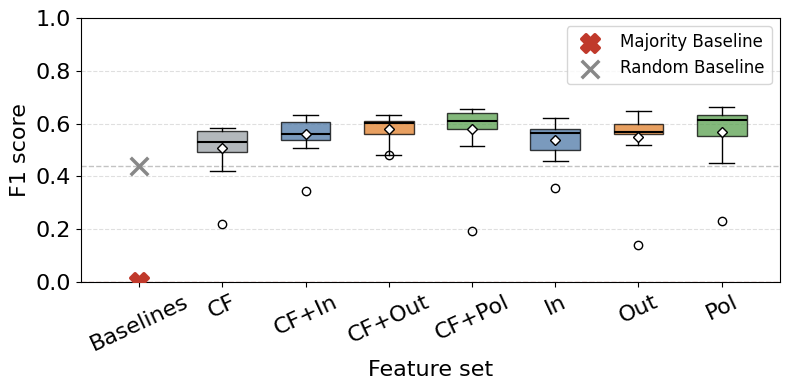

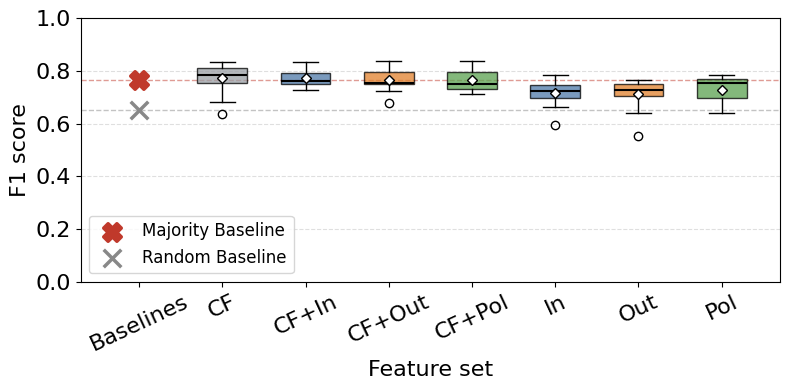

In [13]:
scores_df = scores_df[~scores_df['case'].str.contains('(opt)', regex=False)]
figs, axes = plot_metric_boxplots_per_parliament(
    scores_df, case_order=CASE_ORDER, label_map=LABEL_MAP, color_map=COLOR_MAP)


In [14]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

def _holm(pvals):
    """Holm-Bonferroni adjusted p-values, returned in input order."""
    p = np.asarray(pvals, float)
    m = len(p)
    adj = np.empty(m)
    running = 0.0
    for rank, idx in enumerate(np.argsort(p)):
        running = max(running, (m - rank) * p[idx])   # enforce monotonicity
        adj[idx] = min(running, 1.0)
    return adj

def _rank_biserial(diff):
    """Matched-pairs rank-biserial for signed-rank.
    >0 means comparison_case beats baseline_case on average."""
    d = diff[diff != 0]
    n = len(d)
    if n == 0:
        return np.nan
    ranks = pd.Series(np.abs(d)).rank().to_numpy()
    S = n * (n + 1) / 2
    return (ranks[d > 0].sum() - ranks[d < 0].sum()) / S

def paired_wilcoxon_tests(scores_df, comparisons, metric='f1',
                          alternative='two-sided'):
    """
    comparisons: list of (region, baseline_case, comparison_case).
    Pairs the (<=15) non-baseline classifiers by name and tests whether
    comparison_case differs from baseline_case. Holm is applied across
    ALL rows (the whole family of tests).
    """
    rows = []
    for region, base, comp in comparisons:
        sub = scores_df[(scores_df['region'] == region) &
                        (~scores_df['method'].str.contains('Baseline'))]
        wide = sub.pivot_table(index='method', columns='case', values=metric)
        for c in (base, comp):
            if c not in wide:
                raise KeyError(f"case {c!r} not in region {region!r}; "
                               f"available: {list(wide.columns)}")
        pair = wide[[base, comp]].dropna()
        b, c = pair[base].to_numpy(), pair[comp].to_numpy()
        diff = c - b
        try:
            stat, p = wilcoxon(c, b, alternative=alternative,
                               zero_method='wilcox')
        except ValueError:        # e.g. all differences zero
            p = np.nan
        rows.append({
            'region': region, 'baseline': base, 'comparison': comp,
            'n': len(diff),
            'median_baseline':   np.median(b),
            'median_comparison': np.median(c),
            'median_diff':       np.median(diff),
            'rank_biserial':     _rank_biserial(diff),
            'p_raw':             p,
        })
    out = pd.DataFrame(rows)
    out['p_holm'] = _holm(out['p_raw'].fillna(1.0).to_numpy())
    return out

In [15]:
def _pairs(scores_df, region, case_from, case_to, metric='f1'):
    sub = scores_df[(scores_df['region'] == region) &
                    (~scores_df['method'].str.contains('Baseline'))]
    wide = sub.pivot_table(index='method', columns='case', values=metric)
    for c in (case_from, case_to):
        if c not in wide:
            raise KeyError(f"{c!r} not in region {region!r}; "
                           f"available: {list(wide.columns)}")
    return wide[[case_from, case_to]].dropna()

def summarize(scores_df, region, case_from, case_to, metric='f1'):
    pair = _pairs(scores_df, region, case_from, case_to, metric)
    diff = (pair[case_to] - pair[case_from]).to_numpy()
    n = len(diff)
    n_up   = int((diff > 0).sum())
    n_down = int((diff < 0).sum())
    n_tie  = int((diff == 0).sum())
    return {
        'region': region, 'n': n,
        'mean_diff':   float(diff.mean()),
        'median_diff': float(np.median(diff)),
        'n_up': n_up, 'pct_up': 100 * n_up / n,
        'n_down': n_down, 'pct_down': 100 * n_down / n,
        'n_tie': n_tie,
    }

def plot_slopes(scores_df, regions, case_from, case_to, metric='f1',
                figsize=(4, 6), fontsize=13, label_map=None):
    fig, axes = plt.subplots(1, len(regions), figsize=figsize, sharey=True)
    if len(regions) == 1:
        axes = [axes]
    label_map = label_map or {}
    disp_labels = [label_map.get(c, c) for c in [case_from, case_to]]   # short axis labels

    for ax, region in zip(axes, regions):
        pair = _pairs(scores_df, region, case_from, case_to, metric)
        for _, row in pair.iterrows():
            y0, y1 = row[case_from], row[case_to]
            color = '#2a7a2a' if y1 >= y0 else '#b32020'   # green up / red down
            ax.plot([0, 1], [y0, y1], '-o', color=color, alpha=0.55,
                    markersize=4, linewidth=1.3)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(disp_labels, fontsize=fontsize - 2, ha='right')
        ax.set_xlim(-0.25, 1.25)
        ax.set_title(region, fontsize=fontsize + 1)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.tick_params(axis='y', labelsize=fontsize)
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel(f'{metric.upper()} score', fontsize=fontsize)
    fig.tight_layout()
    return fig, axes


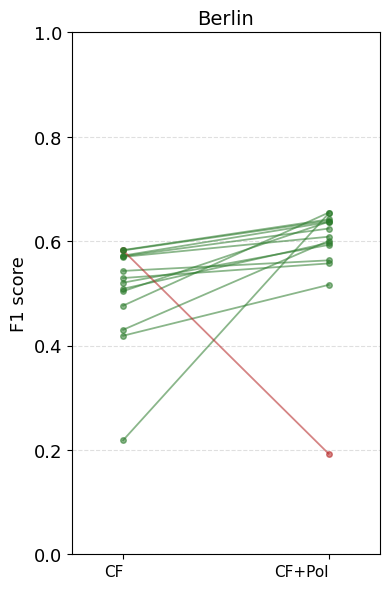

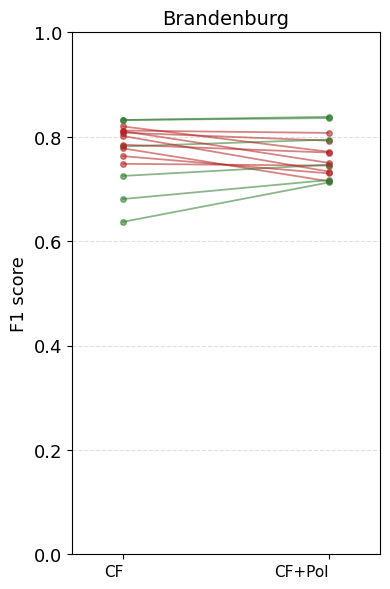

Without political features  ->  Combined

region          nmean deltamedian delta        improved        degraded
-----------------------------------------------------------------------
Berlin         15   +0.074    +0.064     14/15 (93%)       1/15 (7%)
Brandenburg    15   -0.010    -0.005      6/15 (40%)      9/15 (60%)


In [16]:
# --- adjust these to your actual test_cases keys if different ---
CASE_FROM = 'Without political features'
#CASE_TO   = 'Out-of-data political only'
#CASE_TO   = 'Control-flow + out-of-data political'    
CASE_TO = "Combined"
REGIONS   = ['Berlin', 'Brandenburg']

fig, axes = plot_slopes(scores_df, [REGIONS[0]], CASE_FROM, CASE_TO, label_map=LABEL_MAP)
plt.show()
fig, axes = plot_slopes(scores_df, [REGIONS[1]], CASE_FROM, CASE_TO, label_map=LABEL_MAP)
plt.show()


print(f"{CASE_FROM}  ->  {CASE_TO}\n")
hdr = f"{'region':<14}{'n':>3}{'mean delta':>9}{'median delta':>10}{'improved':>16}{'degraded':>16}"
print(hdr); print('-' * len(hdr))
for region in REGIONS:
    s = summarize(scores_df, region, CASE_FROM, CASE_TO)
    up   = f"{s['n_up']}/{s['n']} ({s['pct_up']:.0f}%)"
    down = f"{s['n_down']}/{s['n']} ({s['pct_down']:.0f}%)"
    print(f"{s['region']:<14}{s['n']:>3}{s['mean_diff']:>+9.3f}"
          f"{s['median_diff']:>+10.3f}{up:>16}{down:>16}"
          + (f"   ({s['n_tie']} tied)" if s['n_tie'] else ""))

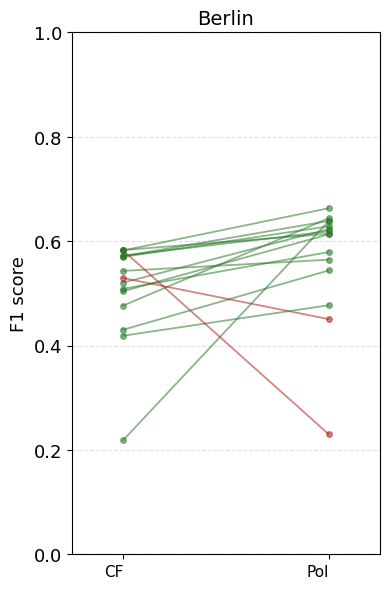

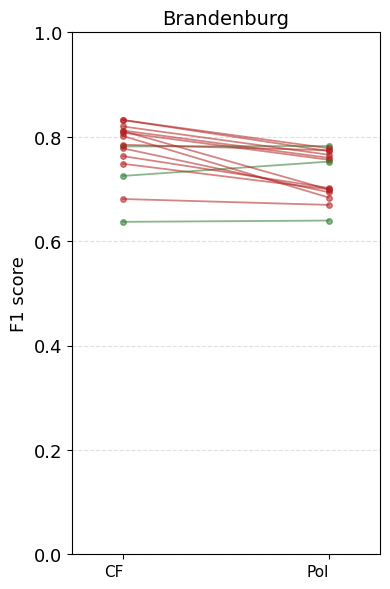

Without political features  ->  Political features only

region          nmean deltamedian delta        improved        degraded
-----------------------------------------------------------------------
Berlin         15   +0.061    +0.068     13/15 (87%)      2/15 (13%)
Brandenburg    15   -0.046    -0.052      3/15 (20%)     12/15 (80%)


In [17]:
# --- adjust these to your actual test_cases keys if different ---
CASE_FROM = 'Without political features'
CASE_TO   = 'Political features only'    
REGIONS   = ['Berlin', 'Brandenburg']

fig, axes = plot_slopes(scores_df, [REGIONS[0]], CASE_FROM, CASE_TO, label_map=LABEL_MAP)
plt.show()
fig, axes = plot_slopes(scores_df, [REGIONS[1]], CASE_FROM, CASE_TO, label_map=LABEL_MAP)
plt.show()

print(f"{CASE_FROM}  ->  {CASE_TO}\n")
hdr = f"{'region':<14}{'n':>3}{'mean delta':>9}{'median delta':>10}{'improved':>16}{'degraded':>16}"
print(hdr); print('-' * len(hdr))
for region in REGIONS:
    s = summarize(scores_df, region, CASE_FROM, CASE_TO)
    up   = f"{s['n_up']}/{s['n']} ({s['pct_up']:.0f}%)"
    down = f"{s['n_down']}/{s['n']} ({s['pct_down']:.0f}%)"
    print(f"{s['region']:<14}{s['n']:>3}{s['mean_diff']:>+9.3f}"
          f"{s['median_diff']:>+10.3f}{up:>16}{down:>16}"
          + (f"   ({s['n_tie']} tied)" if s['n_tie'] else ""))